In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
sns.set(style="whitegrid")

# Data Loading and EDA

In [10]:
df = pd.read_csv("AIML_Dataset.csv")

In [11]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2850748,227,TRANSFER,162916.55,C1998085872,0.0,0.00,C1164478130,1273551.65,1436468.20,0,0
82233,10,PAYMENT,896.38,C544659199,29952.0,29055.62,M1510794408,0.00,0.00,0,0
778000,39,PAYMENT,8489.80,C564623569,0.0,0.00,M1097419974,0.00,0.00,0,0
4125796,302,CASH_OUT,476039.26,C746922665,39933.0,0.00,C1389483976,467478.93,943518.19,0,0
4712083,332,CASH_IN,97178.65,C2060822957,60173.0,157351.65,C392557313,306358.73,209180.07,0,0


In [12]:
df.shape

(6362620, 11)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [14]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [15]:
df[df['isFraud']==1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


In [14]:
df['isFraud'].value_counts() #imbalanced dataset

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [15]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [18]:
df.isnull().sum() # no null values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [20]:
df.duplicated().sum() # no duplicates

np.int64(0)

In [31]:
round((df['isFraud'].value_counts()[1] / df.shape[0]) *100,2) # highly imbalanced

np.float64(0.13)

# Data Analysis

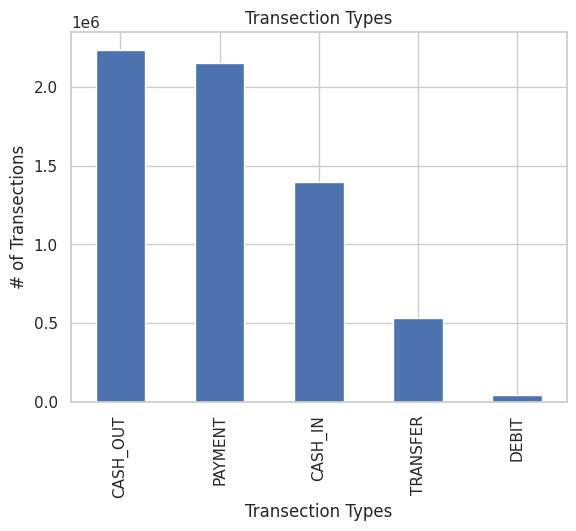

In [38]:
df['type'].value_counts().plot(kind='bar',title = 'Transection Types')
plt.ylabel("# of Transections")
plt.xlabel("Transection Types")
plt.show()

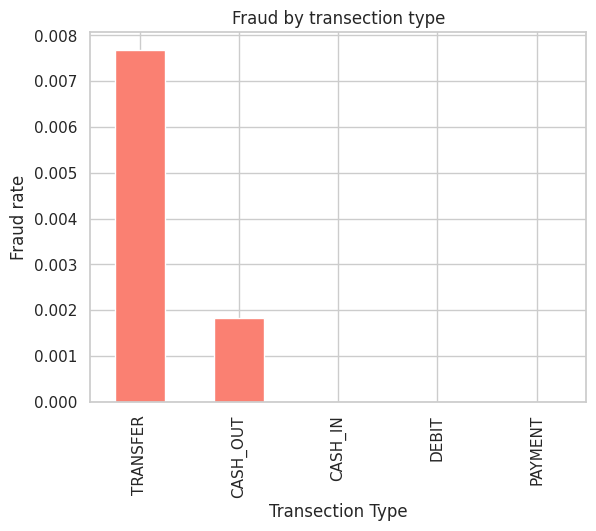

In [44]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar',title='Fraud by transection type',color='salmon')
plt.xlabel("Transection Type")
plt.ylabel("Fraud rate")
plt.show()

In [45]:
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [47]:
df.describe(include='all')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1530544995,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


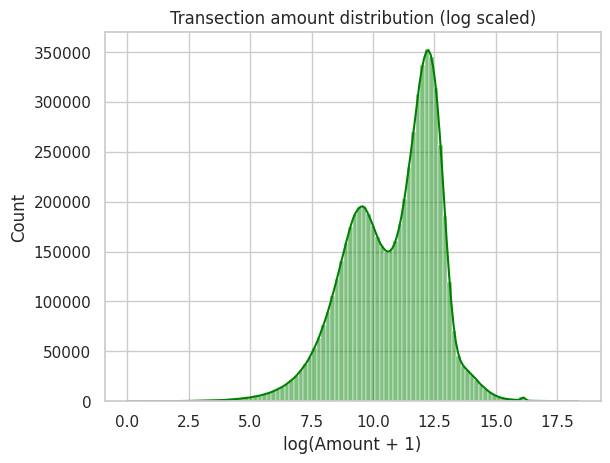

In [49]:
sns.histplot(np.log1p(df['amount']),bins=100,kde=True,color='green')
plt.title("Transection amount distribution (log scaled)")
plt.xlabel("log(Amount + 1)")
plt.show()

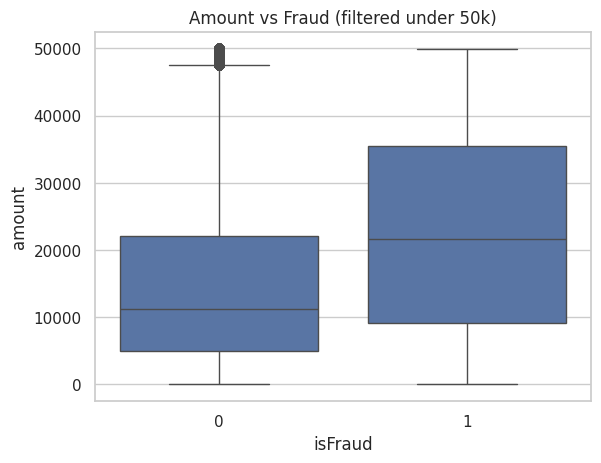

In [51]:
sns.boxplot(df[df['amount']<50000],x = 'isFraud',y ='amount')
plt.title('Amount vs Fraud (filtered under 50k)')
plt.show()

In [56]:
df['balance_diff_Org'] = df['newbalanceOrig']  - df['oldbalanceOrg']
df['balance_diff_Dest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [57]:
(df['balance_diff_Dest']<0).sum()

np.int64(1238864)

In [58]:
(df['balance_diff_Org']<0).sum()

np.int64(2874330)

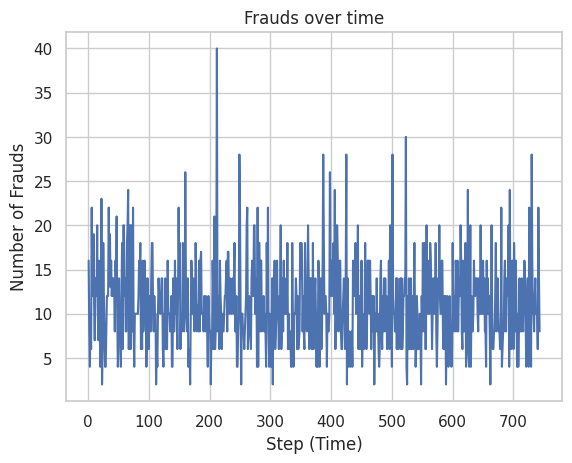

In [63]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index,frauds_per_step.values,label="Frauds Per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds over time")
plt.show() 
# time independent

In [64]:
df.drop(columns = ['step'],inplace=True)

In [65]:
top_senders = df['nameOrig'].value_counts().head(10)

In [66]:
top_senders

nameOrig
C1530544995    3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1065307291    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [67]:
top_recievers = df['nameDest'].value_counts().head(10)
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [68]:
fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)

In [69]:
fraud_users

nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C1039979813    1
C2089752665    1
C1614818636    1
C40604503      1
C1970706589    1
Name: count, dtype: int64

In [72]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

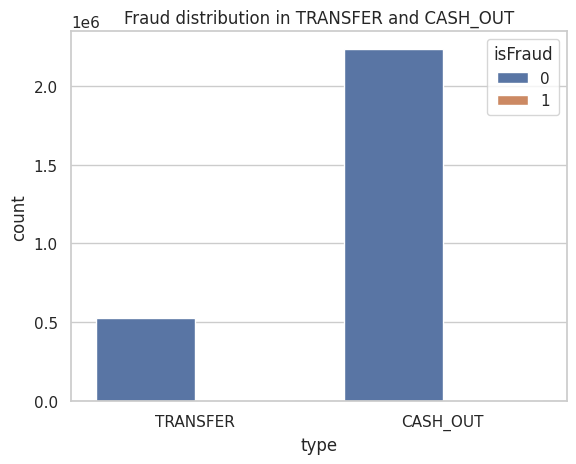

In [76]:
sns.countplot(data = fraud_types,x='type',hue='isFraud')
plt.title("Fraud distribution in TRANSFER and CASH_OUT")
plt.show()

In [78]:
corr = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']].corr()

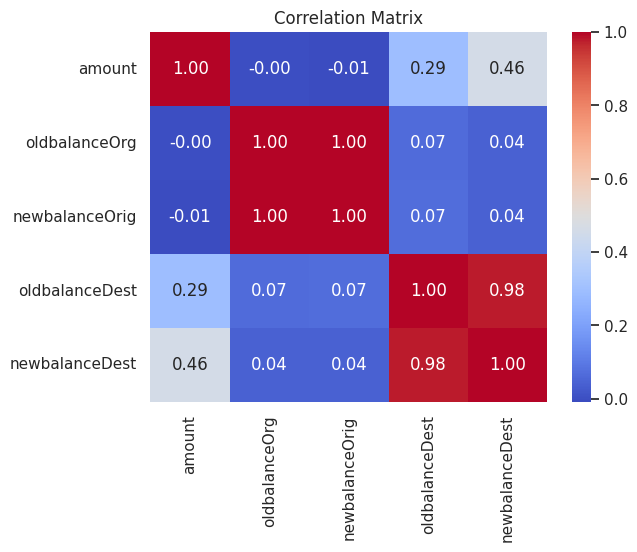

In [83]:
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [86]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(["TRANSFER","cASH_OUT"]))
]

In [87]:
zero_after_transfer.head(5)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_Org,balance_diff_Dest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,-181.00,0.00
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,-705.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,-10835.00,2712905.89
78,TRANSFER,42712.39,C283039401,10363.39,0.0,C1330106945,57901.66,24044.18,0,0,-10363.39,-33857.48
123,TRANSFER,330757.04,C1494346128,103657.00,0.0,C564160838,79676.00,1254956.07,0,0,-103657.00,1175280.07


## Preprocessing and Feature Engineering

In [103]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [90]:
df_model = df.drop(columns = ['nameOrig','nameDest','isFlaggedFraud'],axis = 1)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_Org,balance_diff_Dest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,-9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,-1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,-181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,-181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,-11668.14,0.0


In [91]:
cat_cols = ['type']
num_cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [93]:
y = df_model['isFraud']
X = df_model.drop(columns=['isFraud'])

In [95]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,stratify = y)

In [97]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(drop='first'),cat_cols)
    ],
    remainder='drop'
)

In [99]:
model_pipe = Pipeline([
    ('prep',preprocessor),
    ('clf',LogisticRegression(class_weight='balanced',max_iter=1000))
])

In [100]:
model_pipe.fit(X_train,y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [101]:
y_pred = model_pipe.predict(X_test)

In [102]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.94   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.94      0.97   1908786



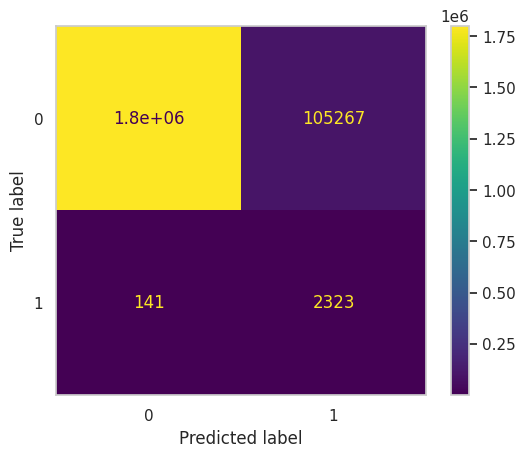

In [115]:
conf = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(conf)
disp.plot()
plt.grid(False)
plt.show()

In [117]:
model_pipe.score(X_test,y_test)

0.9447774658866944

In [118]:
import joblib

joblib.dump(model_pipe,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

In [130]:
l = list(model_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols))

In [131]:
for i,cat in enumerate(l):
    l[i] = cat[5:]

In [132]:
l

['CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']